# Credit Risk Modeling: Probability of Default (PD)

## Business Problem

Financial institutions face significant losses when borrowers fail to repay loans.

The objective of this project is to predict the probability of default for loan applicants using customer demographic, financial, and behavioral information.

This model can help lenders make better credit approval decisions and reduce expected losses.

## Why Credit Risk Matters

When a lender approves a loan, there is always a risk that the borrower may fail to repay.

Poor lending decisions lead to:

- Financial losses
- Increased provisioning
- Reduced profitability
- Higher capital requirements

Therefore, lenders use risk models to estimate default probability before approving a loan.

## Components of Credit Risk

Credit risk is typically measured using:

1. Probability of Default (PD)
2. Loss Given Default (LGD)
3. Exposure at Default (EAD)

Expected Loss = PD × LGD × EAD

This project focuses on building a PD model.

## Problem Statement

Given customer information at the time of loan application,
predict whether the customer will experience repayment difficulties.

Target Variable:

TARGET = 1 → Customer defaulted

TARGET = 0 → Customer did not default

## Model Success Metrics

Since the dataset is imbalanced, accuracy alone is not sufficient.

Primary Metrics:

- ROC-AUC
- Precision
- Recall
- F1 Score

Business Consideration:

Missing a risky customer may result in financial loss.

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/application_train.csv")

print("Shape:", df.shape)

Shape: (307511, 122)


In [2]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [4]:
df["TARGET"].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [5]:
df["TARGET"].value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

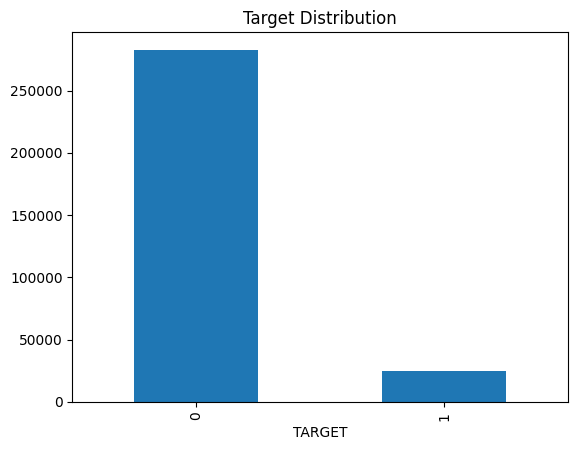

In [7]:
import matplotlib.pyplot as plt

df["TARGET"].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.show()

### Key Observation

The target variable is imbalanced, with approximately 8% of customers experiencing repayment difficulties.

This implies that accuracy alone is not a reliable metric for model evaluation.

The project will primarily use ROC-AUC, Precision, Recall, and F1 Score to assess model performance.